# Lakeside heating DSM — sklearn hybrid (train + ship)

**This notebook is the only supported train path.** CLI trainers refuse unless `VIBE22_ALLOW_CLI_TRAIN=1`.

| Component | What | Provenance |
|---|---|---|
| A | Real BAS 15-min baseline (7 outs) | `REAL_BAS_15MIN` |
| B | Paired E+ IdealLoads+COP deltas | `ENERGYPLUS_NATIVE_RUN` → delta |
| C | Hybrid 96-step walk | `HYBRID_SCREENING` |

Set `LAKESIDE_SITE_ROOT`. Default knobs are **lean** (winter, ~36 days, fixed hyperparams). Set `FULL=True` for nested CV.


## 0 · Setup


In [1]:
from pathlib import Path
import sys, json, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, Markdown

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT / "ml"))
sys.path.insert(0, str(ROOT / "scripts"))

# Drop stale ml modules if this kernel ran an older vibe22 checkout
for _mod in (
    "notebook_proof",
    "notebook_plots",
    "artifact_paths",
    "train_real_baseline_15min",
    "train_eplus_delta_15min",
    "promote_hybrid_ship",
):
    sys.modules.pop(_mod, None)

from artifact_paths import artifact_paths, train_parquet_path
from notebook_proof import prove_native_farm_load, prove_real_store_load
from notebook_plots import save_fig
from train_real_baseline_15min import (
    load_real_baseline_frame,
    lean_bake_off,
    nested_bake_off,
    export_real_baseline_artifacts,
)
from train_eplus_delta_15min import (
    load_paired_and_build_delta,
    lean_train_delta,
    train_delta,
    export_delta_artifacts,
)
from promote_hybrid_ship import promote_hybrid

PATHS = artifact_paths()
PATHS["figures"].mkdir(parents=True, exist_ok=True)
OUT = PATHS["figures"].parent  # ml/artifacts
SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))

# --- knobs (lean default for Run All) ---
FULL = False          # True → nested CV (slow)
WINTER_ONLY = True
MAX_DAYS = 36         # None = all winter days
N_SPLITS = 3

print("ROOT", ROOT)
print("SITE", SITE)
print("OUT", OUT)
print("FULL", FULL, "MAX_DAYS", MAX_DAYS)
print("prove_real_store_load OK:", prove_real_store_load.__name__)

PATHS = artifact_paths()
PATHS["figures"].mkdir(parents=True, exist_ok=True)
OUT = PATHS["figures"].parent  # ml/artifacts
SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))

# --- knobs (lean default for Run All) ---
FULL = False          # True → nested CV (slow)
WINTER_ONLY = True
MAX_DAYS = 36         # None = all winter days
N_SPLITS = 3

print("ROOT", ROOT)
print("SITE", SITE)
print("OUT", OUT)
print("FULL", FULL, "MAX_DAYS", MAX_DAYS)


ROOT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22
SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside
OUT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts
FULL False MAX_DAYS 36
prove_real_store_load OK: prove_real_store_load
ROOT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22
SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside
OUT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts
FULL False MAX_DAYS 36


## 1 · Proof — real BAS 15-min store (component A data)


In [2]:
real_df, real_meta = prove_real_store_load(site=SITE)
assert (real_df["provenance"] == "REAL_BAS_15MIN").all()
print("real rows", len(real_df), "days", real_df["day"].nunique())


### Proof — real BAS 15-min store (component A)
- **Parquet:** `C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\ml\artifacts\real_baseline_15min_v1.parquet`
- **Rows / days:** 32156 / 335
- **Provenance:** `REAL_BAS_15MIN` (no EnergyPlus rows)
- **Zone temp columns:** ['zone_temp_1F_A_f', 'zone_temp_1F_B_f', 'zone_temp_1F_C_f', 'zone_temp_1F_D_f', 'zone_temp_2F_A_f', 'zone_temp_2F_B_f']
- **Honesty:** measured BAS only — hybrid baseline component
- **Build row_count:** 32156

,day,step_15,facility_kw,oat_f,zone_temp_1F_A_f,zone_temp_1F_B_f,provenance
0,2025-08-02,0,26.0,56.800000,69.655556,72.295833,REAL_BAS_15MIN
1,2025-08-02,1,24.0,56.566667,69.663889,72.391667,REAL_BAS_15MIN
2,2025-08-02,2,26.0,56.366667,69.586111,72.445833,REAL_BAS_15MIN
3,2025-08-02,3,24.0,56.166667,69.638889,72.454167,REAL_BAS_15MIN
4,2025-08-02,4,28.0,55.966667,69.566667,72.462500,REAL_BAS_15MIN
5,2025-08-02,5,26.0,55.650000,69.625000,72.450000,REAL_BAS_15MIN
6,2025-08-02,6,24.0,55.275000,69.522222,72.425000,REAL_BAS_15MIN
7,2025-08-02,7,26.0,54.900000,69.550000,72.433333,REAL_BAS_15MIN


real rows 32156 days 335


## 2 · Proof — paired native E+ farm (component B data)


In [3]:
farm_df, farm_meta = prove_native_farm_load(root=ROOT, paths=PATHS, site=SITE)
assert train_parquet_path().resolve() == PATHS["eplus_paired"].resolve()
assert "arm" in farm_df.columns and set(farm_df["arm"].unique()) >= {"baseline", "dsm"}
zcols = [c for c in farm_df.columns if c.startswith("zone_temp_") and c.endswith("_f")]
assert len(zcols) == 6, zcols
print("farm OK", farm_meta["farm_path"])


### Proof — training labels are native EnergyPlus (not BAS proxy)
- **Farm parquet:** `C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\heating_dsm_eplus_paired_15min_v1.parquet`
- **Rows / runs / days:** 1728 / 12 / 6
- **Provenance (summary):** `ENERGYPLUS_NATIVE_RUN`
- **Provenance (row counts):** `{'ENERGYPLUS_NATIVE_RUN': 1728}`
- **Honesty:** `HYBRID_SCREENING`
- **Site root:** `C:\Users\ben\OneDrive\Desktop\testing\sp_creekside`
- **Champion IDF (Lakeside rename of Creekside):** `lakeside_6zone_gshp_best_utility.idf`
  - SHA-256: `23EBE5207BC6D30A64C50EF969281F243719DBB720E36F0A8BC0108D7F5EA83B`
- **Creekside alias same bytes:** `True`
- **Staged DSM IDF:** `lakeside_6zone_gshp_best_utility_dsm_v1.idf`
  - SHA-256: `169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F02A468715829A4A7EB` (matches DSM_ELIGIBLE: `169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F02A468715829A4A7EB`)
- **EPW SHA-256 (farm):** `DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE03865873D707D04EE22608D3`
- **Monthly GL14 (staged):** `pass` · NMBE=2.728% · CVRMSE=11.596%

IdealLoads + fixed COP is the twin's electric demand model (not a fake kW formula). Hybrid path trains deltas separately from real BAS baseline — never concat rows. There is **no** `BAS_BOOTSTRAP_PROXY` / `physics_proxy_kw` path anymore.

#### First 12 farm rows (human inspection)

,day,pair_id,arm,hour_ending,quarter_index,strategy_id,control_regime,facility_kw,zone_temp_1F_A_f,provenance,input_hash,idf_sha256,epw_sha256,run_id,oat_f,heat_cop_proxy
0,2026-01-05,2026-01-05__baseline,baseline,24,0,baseline,baseline,12.406851,49.855436,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,30.895833,3.5
1,2026-01-05,2026-01-05__baseline,baseline,24,1,baseline,baseline,12.406851,49.591558,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,30.895833,3.5
2,2026-01-05,2026-01-05__baseline,baseline,24,2,baseline,baseline,12.406851,49.305505,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,30.895833,3.5
3,2026-01-05,2026-01-05__baseline,baseline,1,3,baseline,baseline,12.406851,49.018881,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,31.187500,3.5
4,2026-01-05,2026-01-05__baseline,baseline,1,4,baseline,baseline,12.406851,48.820960,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,31.187500,3.5
5,2026-01-05,2026-01-05__baseline,baseline,1,5,baseline,baseline,12.406851,48.696940,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,31.187500,3.5
6,2026-01-05,2026-01-05__baseline,baseline,1,6,baseline,baseline,12.406851,48.596139,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,31.187500,3.5
7,2026-01-05,2026-01-05__baseline,baseline,2,7,baseline,baseline,12.406851,48.491927,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,30.287500,3.5
8,2026-01-05,2026-01-05__baseline,baseline,2,8,baseline,baseline,12.406851,48.377885,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,30.287500,3.5
9,2026-01-05,2026-01-05__baseline,baseline,2,9,baseline,baseline,12.406851,48.260607,ENERGYPLUS_NATIVE_RUN,0f3c0e8fed3c6c77930f78aba038ed4825f33fc956df85...,169BF9FE007C7A3963ECDE31FDF07D7503DE77B3C91C6F...,DBFD1148A6627B53A1C6D5BA5E7B5FE7C4733FBE038658...,2026-01-05_baseline_0f3c0e8fed3c,30.287500,3.5


#### Provenance / strategy / arm counts

,count
provenance,
ENERGYPLUS_NATIVE_RUN,1728


,count
strategy_id,
baseline,576
stagger_preheat,192
flat_24_7,192
deep_setback,192
morning_all_on,192
prbs_z0,192
prbs_z1,192


,count
arm,
baseline,1152
dsm,576


farm OK C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\heating_dsm_eplus_paired_15min_v1.parquet


## 3 · EDA — measured kW vs OAT + paired arms


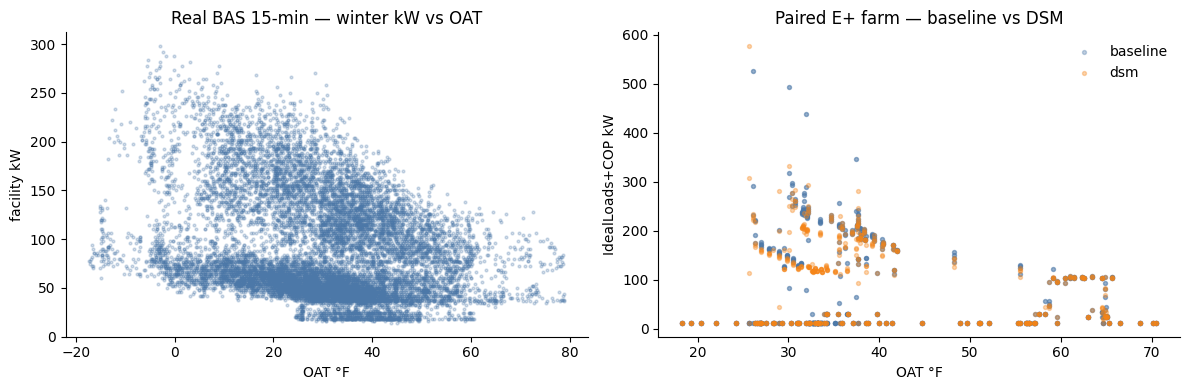

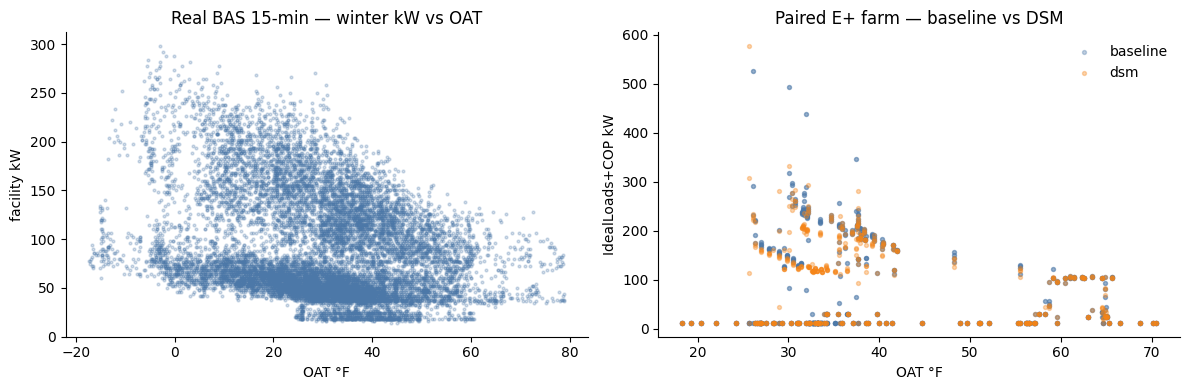

In [4]:
winter = real_df[real_df["month"].isin([11, 12, 1, 2, 3])].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(winter["oat_f"], winter["facility_kw"], s=4, alpha=0.25, c="#4C78A8")
axes[0].set_xlabel("OAT °F"); axes[0].set_ylabel("facility kW")
axes[0].set_title("Real BAS 15-min — winter kW vs OAT")
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

for arm, color in (("baseline", "#4C78A8"), ("dsm", "#F58518")):
    sub = farm_df[farm_df["arm"] == arm]
    axes[1].scatter(sub["oat_f"], sub["facility_kw"], s=8, alpha=0.35, label=arm, c=color)
axes[1].set_xlabel("OAT °F"); axes[1].set_ylabel("IdealLoads+COP kW")
axes[1].set_title("Paired E+ farm — baseline vs DSM")
axes[1].legend(frameon=False)
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
plt.tight_layout()
save_fig(PATHS["figures"] / "hybrid_eda_kw_oat.png", fig)
display(fig)
plt.close(fig)


## 4 · Train component A — real baseline (writes cards + ONNX)


In [5]:
train_df = load_real_baseline_frame(winter_only=WINTER_ONLY, max_days=MAX_DAYS)
print("train rows", len(train_df), "days", train_df["day"].nunique())

if FULL:
    base_result = nested_bake_off(train_df, outer_splits=N_SPLITS, inner_splits=2, n_iter=6)
else:
    base_result = lean_bake_off(train_df, n_splits=N_SPLITS)

base_paths = export_real_baseline_artifacts(base_result, OUT)
base_card = json.loads(base_paths["card"].read_text(encoding="utf-8"))
display(Markdown(f"### Real baseline champion: **{base_card['champion']}**"))
print(json.dumps(base_result["cv_teacher_forced"], indent=2))


train rows 3456 days 36
lean fold 1/3
  random_forest peak MAE=9.621
  extra_trees peak MAE=9.365
  gradient_boosting peak MAE=9.837
lean fold 2/3
  random_forest peak MAE=10.386
  extra_trees peak MAE=9.699
  gradient_boosting peak MAE=10.845
lean fold 3/3
  random_forest peak MAE=11.222
  extra_trees peak MAE=10.786
  gradient_boosting peak MAE=11.268


### Real baseline champion: **extra_trees**

{
  "random_forest": {
    "facility_kw": {
      "mae": 7.00062831307486,
      "rmse": 10.35141232084061,
      "mae_peak_05_09": 10.409670882694341,
      "rmse_peak_05_09": 14.211130392503529
    },
    "zone_temp_1F_A_f": {
      "mae": 0.07194114892264132,
      "rmse": 0.10930323038197143,
      "mae_peak_05_09": 0.09990255405162195,
      "rmse_peak_05_09": 0.13886745010843535
    },
    "zone_temp_1F_B_f": {
      "mae": 0.08119197413953762,
      "rmse": 0.1309359703840449,
      "mae_peak_05_09": 0.11042275653995444,
      "rmse_peak_05_09": 0.15529441792364837
    },
    "zone_temp_1F_C_f": {
      "mae": 0.07960579380881701,
      "rmse": 0.1304683606601912,
      "mae_peak_05_09": 0.08801051154154516,
      "rmse_peak_05_09": 0.12991488472662954
    },
    "zone_temp_1F_D_f": {
      "mae": 0.09961843135152197,
      "rmse": 0.14908872052859912,
      "mae_peak_05_09": 0.12302301049432394,
      "rmse_peak_05_09": 0.16406197925096153
    },
    "zone_temp_2F_A_f": {
     

## 5 · Train component B — E+ delta (writes cards + ONNX)


In [6]:
delta_df, paired_path = load_paired_and_build_delta(PATHS["eplus_paired"], out_dir=OUT)
if FULL:
    delta_result = train_delta(delta_df, outer_splits=N_SPLITS, n_iter=4)
else:
    delta_result = lean_train_delta(delta_df, n_splits=N_SPLITS)

delta_paths = export_delta_artifacts(delta_result, OUT, paired_source=str(paired_path))
delta_card = json.loads(delta_paths["card"].read_text(encoding="utf-8"))
display(Markdown(f"### E+ delta champion: **{delta_card['champion']}**"))
print(json.dumps(delta_result["cv_teacher_forced"], indent=2))


delta rows=576 pairs=6 -> C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\eplus_delta_15min_v1.parquet
lean delta fold 1/3
  random_forest peak ΔMAE=57.408
  extra_trees peak ΔMAE=53.344
  gradient_boosting peak ΔMAE=58.010
lean delta fold 2/3
  random_forest peak ΔMAE=20.283
  extra_trees peak ΔMAE=24.832
  gradient_boosting peak ΔMAE=22.700
lean delta fold 3/3
  random_forest peak ΔMAE=35.514
  extra_trees peak ΔMAE=37.630
  gradient_boosting peak ΔMAE=30.970


### E+ delta champion: **gradient_boosting**

{
  "random_forest": {
    "mae_delta_kw": 11.221939511578299,
    "rmse_delta_kw": 30.90975609554116,
    "mae_delta_kw_peak": 37.73494391069087,
    "mae_delta_temp_mean": 1.398965103162921
  },
  "extra_trees": {
    "mae_delta_kw": 17.23765242984798,
    "rmse_delta_kw": 41.81523733578725,
    "mae_delta_kw_peak": 38.601683392337186,
    "mae_delta_temp_mean": 1.2122813520963975
  },
  "gradient_boosting": {
    "mae_delta_kw": 16.010457497337203,
    "rmse_delta_kw": 35.80432942779236,
    "mae_delta_kw_peak": 37.226443703763316,
    "mae_delta_temp_mean": 1.7290804449378705
  }
}


## 6 · Leaderboard charts


,family,mae,mae_peak_05_09,zone_temp_mae_mean
0,extra_trees,7.146,9.95,0.093
1,random_forest,7.001,10.41,0.091
2,gradient_boosting,7.253,10.65,0.084


,family,mae_delta_kw,rmse_delta_kw,mae_delta_kw_peak,mae_delta_temp_mean
2,gradient_boosting,16.010,35.804,37.226,1.729
0,random_forest,11.222,30.910,37.735,1.399
1,extra_trees,17.238,41.815,38.602,1.212


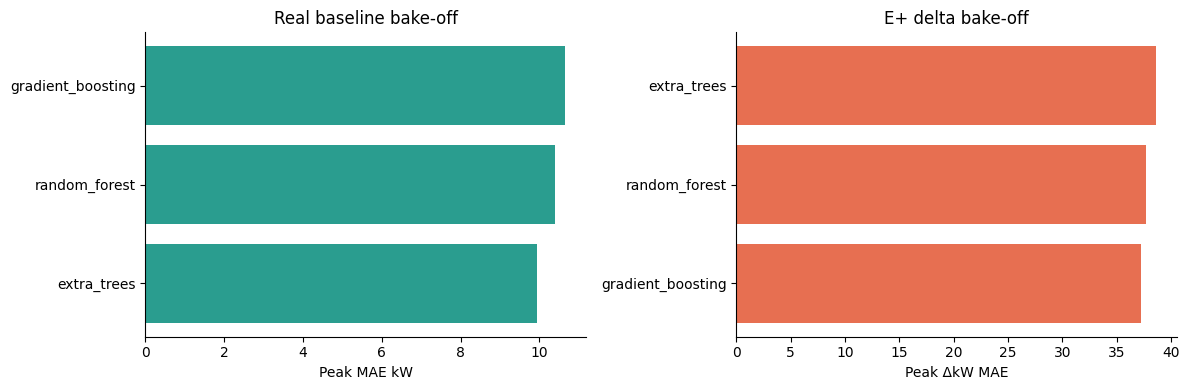

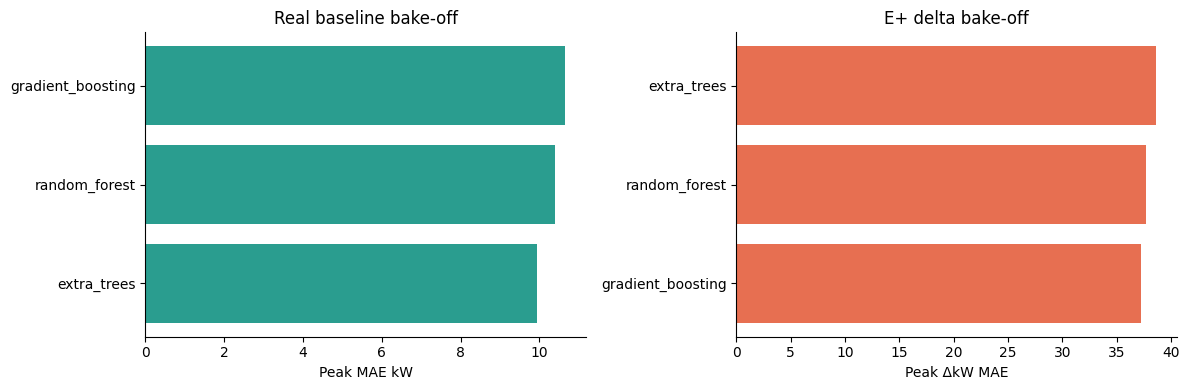

In [7]:
cv = base_card["cv_teacher_forced"]
lb = pd.DataFrame([
    {
        "family": fam,
        "mae": m.get("facility_kw_mae", m.get("facility_kw", {}).get("mae")),
        "mae_peak_05_09": m.get(
            "facility_kw_mae_peak_05_09",
            m.get("facility_kw", {}).get("mae_peak_05_09"),
        ),
        "zone_temp_mae_mean": m.get("zone_temp_mae_mean"),
    }
    for fam, m in cv.items()
]).sort_values("mae_peak_05_09").reset_index(drop=True)
display(lb.round(3))

dcv = delta_card["cv_teacher_forced"]
dlb = pd.DataFrame([{"family": k, **v} for k, v in dcv.items()]).sort_values("mae_delta_kw_peak")
display(dlb.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(lb["family"], lb["mae_peak_05_09"], color="#2a9d8f")
axes[0].set_xlabel("Peak MAE kW"); axes[0].set_title("Real baseline bake-off")
axes[1].barh(dlb["family"], dlb["mae_delta_kw_peak"], color="#e76f51")
axes[1].set_xlabel("Peak ΔkW MAE"); axes[1].set_title("E+ delta bake-off")
for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig(PATHS["figures"] / "hybrid_sklearn_leaderboards.png", fig)
display(fig)
plt.close(fig)


## 7 · Promote hybrid 96-step walk (desktop ship)


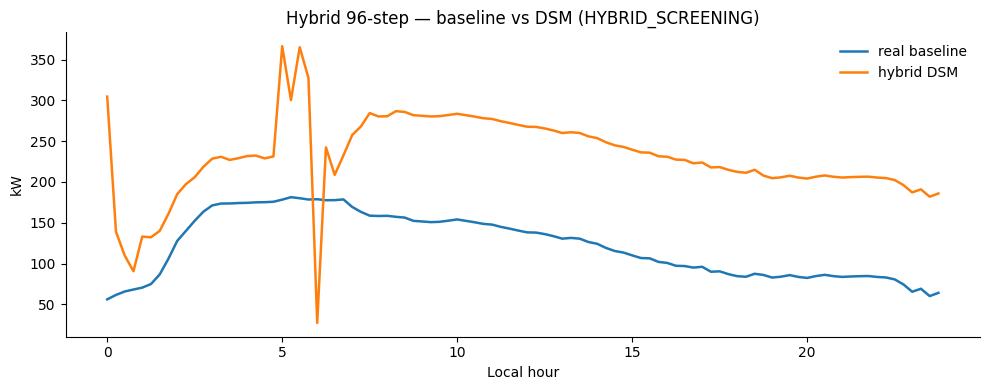

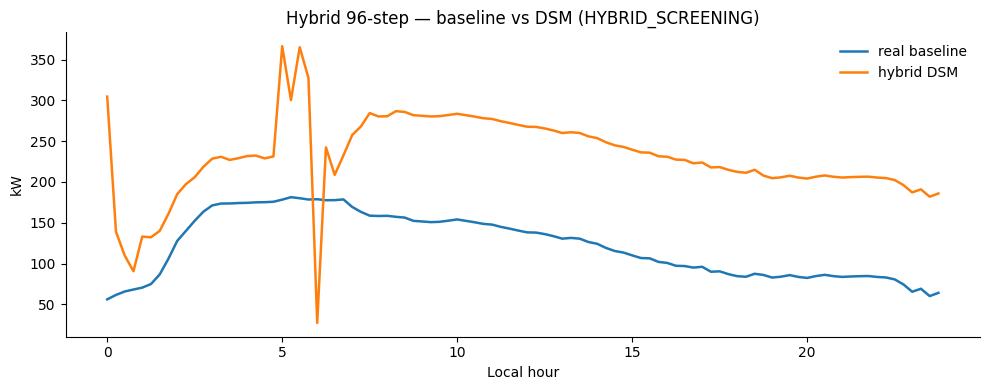

### Walk summary

,value
cumulative_kwh_baseline,2927.368682
cumulative_kwh_hybrid,5546.262077
peak_kw_baseline,181.344444
peak_kw_hybrid,366.414554
peak_step_baseline,21.000000
peak_step_hybrid,20.000000
comfort_violations,23.000000
delta_peak_kw,185.070110
delta_kwh,2618.893395


walk C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\hybrid_dsm_96_v1_walk.json
champions extra_trees + gradient_boosting


In [8]:
promo = promote_hybrid(artifacts=OUT, desktop_artifacts=ROOT / "desktop" / "artifacts")
walk = promo["result"]
assert walk.get("honesty") == "HYBRID_SCREENING"
assert len(walk["steps"]) == 96

steps = pd.DataFrame(walk["steps"])
steps["hour"] = steps["step_15"] / 4.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps["hour"], steps["baseline_facility_kw"], label="real baseline", lw=1.8)
ax.plot(steps["hour"], steps["hybrid_facility_kw"], label="hybrid DSM", lw=1.8)
ax.set_xlabel("Local hour"); ax.set_ylabel("kW")
ax.set_title("Hybrid 96-step — baseline vs DSM (HYBRID_SCREENING)")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig(PATHS["figures"] / "hybrid_96_walk_kw.png", fig)
display(fig)
plt.close(fig)

display(Markdown("### Walk summary"))
display(pd.Series(walk["summary"]).to_frame("value"))
print("walk", promo["walk"])
print("champions", walk.get("champion_baseline"), "+", walk.get("champion_delta"))


## Honesty

- IdealLoads + fixed COP ≠ GSHP plant.
- Real BAS and E+ rows are **never** concatenated for training.
- `HYBRID_SCREENING` until field DSM trials.
- Model training only via this notebook (CLI gated).
